# Time model Training

Timing reconstruction training pipeline for the SBND detector. Uses a LSTM or a Transformer architecture (~0.5M parameters) to predict neutrino vertex position timing (nuvT) from PMT light images.

### Import all required libraries
Load every Python package used throughout the notebook:
- **numpy / pandas** — numerical arrays and tabular data
- **uproot / awkward** — read ROOT files (the LArSoft output format) without ROOT
- **TensorFlow / Keras** — model definition, training, and callbacks
- **sklearn** — feature scaling and train/val/test splitting
- **matplotlib / scipy** — plotting and statistical fitting


In [1]:
import os, glob, shutil, time, json, concurrent.futures
import numpy as np
import uproot
import awkward as ak
import pandas as pd
import tensorflow as tf
import keras
from keras.layers import Dense, LayerNormalization, MultiHeadAttention, Dropout
from keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
from scipy.stats import norm as scipy_norm
import matplotlib.pyplot as plt
from IPython.display import display as ipy_display

try:
    from numba import jit, prange
    HAS_NUMBA = True
except ImportError:
    HAS_NUMBA = False
    def jit(*args, **kwargs):
        def decorator(func): return func
        return decorator
    prange = range

os.environ['TF_CPP_MIN_LOG_LEVEL'] = '2'
print('TF:', tf.__version__)
print('GPUs:', tf.config.list_physical_devices('GPU'))

2026-04-15 10:14:10.282247: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:10575] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2026-04-15 10:14:10.282364: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:479] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2026-04-15 10:14:10.284101: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1442] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2026-04-15 10:14:10.290119: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: SSE4.1 SSE4.2 AVX AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


TF: 2.16.2
GPUs: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


2026-04-15 10:14:16.612380: I external/local_xla/xla/stream_executor/cuda/cuda_executor.cc:998] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero. See more at https://github.com/torvalds/linux/blob/v6.0/Documentation/ABI/testing/sysfs-bus-pci#L344-L355
2026-04-15 10:14:16.665873: I external/local_xla/xla/stream_executor/cuda/cuda_executor.cc:998] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero. See more at https://github.com/torvalds/linux/blob/v6.0/Documentation/ABI/testing/sysfs-bus-pci#L344-L355
2026-04-15 10:14:16.666329: I external/local_xla/xla/stream_executor/cuda/cuda_executor.cc:998] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero. See more at https://github.com/torvalds/linux/blob/v6.0/Documentation/ABI/testing/sysfs-bus-pci#L344-

### Load custom plot style
Import the shared `plot_style` module that defines consistent colors, fonts, and figure sizes used across all notebooks in the project. Reloading it here ensures any recent edits to the style file take effect.

In [2]:
import sys
sys.path.insert(0, '/exp/sbnd/app/users/svidales/larsoft_develop/srcs/sbndcode/sbndcode/NuIntNNOpReco/2-cnn-training-notebooks/')
from plot_style import *

### Create a timestamped run directory
All models, scalers, and plots produced during this run are saved under a unique folder named with the current date and time (e.g. `run_20241020_1430`). This prevents accidentally overwriting results from previous training runs. The clock is set to CEST (UTC+2) to match local lab time.

In [4]:
# ── Run directory: models and plots are saved here ────────────────────────────
import os
from datetime import datetime, timezone, timedelta

BASE_RUNS = '/exp/sbnd/data/users/svidales/AI_nuvT_project_support/AA_FinalPlots/temporal/runs'
_cest   = timezone(timedelta(hours=2))  # CEST = UTC+2
_ts     = datetime.now(_cest).strftime('%Y%m%d_%H%M')
RUN_DIR = os.path.join(BASE_RUNS, 'run_' + _ts)
os.makedirs(RUN_DIR, exist_ok=True)
print(f'>> Run directory: {RUN_DIR}')

>> Run directory: /exp/sbnd/data/users/svidales/AI_nuvT_project_support/AA_FinalPlots/temporal/runs/run_20260415_1214


### 1. Loading DATA from PosRecoCVNDataPrep_module.cc

### Load data and build input features
This is the main data-loading cell. It performs several steps:

1. **ToF correction constant**: defines `C_LIGHT_CM_NS` (speed of light in cm/ns) used to remove the time-of-flight offset `nuvZ / c` from the neutrino time label, so the model learns the interaction time relative to the beam bunch rather than the absolute arrival time.

2. **Load labels and optical hits**: reads the neutrino vertex time `nuvT`, vertex Z position `nuvZ`, and the per-event ophit sequences (time, PE, channel position, detector type) from the ROOT file produced by `PosRecoCVNDataPrep_module.cc`.

3. **Feature engineering**: for each event, the ophit sequence is assembled into a fixed-length padded matrix. The last feature column is `delta_t`, the time difference between consecutive ophits, which encodes the temporal structure of the optical signal.

4. **Train/val/test split** (70 / 15 / 15 %): the split is computed on event indices before feature normalization to avoid data leakage.

In [5]:
C_LIGHT_CM_NS = 29.9792458  # cm/ns — ToF correction: nuvZ/c

# ─────────────────────────────────────────────────────────────────────────────
# Load data from ROOT (training_data_def_v1603.root)
# Split 70 / 15 / 15  (train / val / test)
# ─────────────────────────────────────────────────────────────────────────────

ROOT_FILE = '/exp/sbnd/data/users/svidales/AI_nuvT_project_support/AA_FinalPlots/AA_MC_samples/FallProd/FallProd_complete_dataset_v1603.root'
SEED      = 42

import time as _t
_t0 = _t.time()
print('Loading ROOT file...')
f_root = uproot.open(ROOT_FILE)

# ── 1. Channel geometry ───────────────────────────────────────────────────────
pds = f_root['dataprep/PDSMapTree'].arrays(
    ['OpDetID','OpDetType','OpDetX','OpDetY','OpDetZ'], entry_stop=312, library='np')
channel_geom_ref = {
    int(pds['OpDetID'][i]): (int(pds['OpDetType'][i]),
                              float(pds['OpDetX'][i]),
                              float(pds['OpDetY'][i]),
                              float(pds['OpDetZ'][i]))
    for i in range(312)}
print(f'  channel_geom_ref: {len(channel_geom_ref)} channels  ({_t.time()-_t0:.1f}s)')

# ── 2. Labels ─────────────────────────────────────────────────────────────────
AV = {'x': (-200.0, 200.0), 'y': (-200.0, 200.0), 'z': (0.0, 500.0)}

lab = f_root['dataprep/labels/tree'].arrays(
    ['passed_filters', 'selected_tpc',
     'nuv_t', 'nuv_x', 'nuv_y', 'nuv_z',
     'dEprom_x', 'dEprom_y', 'dEprom_z'], library='ak')

ok   = np.array(lab['passed_filters'], dtype=bool)
stpc = np.array(lab['selected_tpc'],   dtype=np.int32)
print(f'  passed_filters: {ok.sum():,} / {len(ok):,}  ({_t.time()-_t0:.1f}s)')

# nuvT/X/Y/Z: first neutrino inside the active volume (same criterion as C++ module)
in_av = ((lab['nuv_x'] >= AV['x'][0]) & (lab['nuv_x'] <= AV['x'][1]) &
          (lab['nuv_y'] >= AV['y'][0]) & (lab['nuv_y'] <= AV['y'][1]) &
          (lab['nuv_z'] >= AV['z'][0]) & (lab['nuv_z'] <= AV['z'][1]))

nuvT_all = np.array(ak.firsts(lab['nuv_t'][in_av])[ok], dtype=np.float32)
nuvX_all = np.array(ak.firsts(lab['nuv_x'][in_av])[ok], dtype=np.float32)
nuvY_all = np.array(ak.firsts(lab['nuv_y'][in_av])[ok], dtype=np.float32)
nuvZ_all = np.array(ak.firsts(lab['nuv_z'][in_av])[ok], dtype=np.float32)

# dEprom: indexed by TPC (always 2 elements: [TPC0, TPC1])
def get_tpc_label(arr_ak, ok_mask, tpc_idx):
    ok_arr = ak.to_list(arr_ak[ok_mask])
    return np.array([row[t] for row, t in zip(ok_arr, tpc_idx)], dtype=np.float32)

stpc_ok     = stpc[ok]
dEpromx_all = get_tpc_label(lab['dEprom_x'], ok, stpc_ok)
dEpromy_all = get_tpc_label(lab['dEprom_y'], ok, stpc_ok)
dEpromz_all = get_tpc_label(lab['dEprom_z'], ok, stpc_ok)
print(f'  labels extracted  ({_t.time()-_t0:.1f}s)')

# ── 3. Temporal features (N, 20, 7) ──────────────────────────────────────────
# Feature layout: [t_us, logPE_norm, det_type, x_norm, y_norm, z_norm, delta_t_us]
# t_us already ToF-corrected: t_ophit - nuvZ/c  (applied in C++ module)
temp_ak = f_root['dataprep/temporal/tree'].arrays(
    ['temporal_features', 'temporal_seq_len'], library='ak')
seq_len = int(ak.to_numpy(temp_ak['temporal_seq_len'][ok])[0])  # = 20
X_flat  = ak.to_numpy(temp_ak['temporal_features'][ok])         # (N_ok, 140)
X_all   = X_flat.reshape(-1, seq_len, 7).astype(np.float32)
print(f'  temporal features: {X_all.shape}  ({_t.time()-_t0:.1f}s)')

# ── 4. Label: nuvT_tof = nuvT - nuvZ/c [ns] ──────────────────────────────────
label_all = (nuvT_all - nuvZ_all / C_LIGHT_CM_NS).astype(np.float32)

# ── 4.5. Remove events with unphysical ophit times (t_us < 0) ────────────────
# t_us is ToF-corrected arrival time; negative values are unphysical.
# Check only real (non-padded) steps: padding uses -1000.0
_PADVAL   = -1000.0
_real     = X_all[:, :, 0] != _PADVAL                            # (N, 20) bool
_t_min    = np.where(_real, X_all[:, :, 0], np.inf).min(axis=1) # min t_us per event
phys_ok   = _t_min >= 0.0
n_removed = int((~phys_ok).sum())
print(f'  Events with t_us < 0: {n_removed:,} removed  ({phys_ok.sum():,} kept)  ({_t.time()-_t0:.1f}s)')

X_all       = X_all[phys_ok]
label_all   = label_all[phys_ok]
nuvT_all    = nuvT_all[phys_ok];   nuvX_all = nuvX_all[phys_ok]
nuvY_all    = nuvY_all[phys_ok];   nuvZ_all = nuvZ_all[phys_ok]
dEpromx_all = dEpromx_all[phys_ok]
dEpromy_all = dEpromy_all[phys_ok]
dEpromz_all = dEpromz_all[phys_ok]

# ── 5. Split 70 / 15 / 15 ────────────────────────────────────────────────────
N = len(label_all)
idx_tr, idx_tmp = train_test_split(np.arange(N), test_size=0.30, random_state=SEED)
idx_val, idx_te = train_test_split(idx_tmp,       test_size=0.50, random_state=SEED)
idx_tr.sort(); idx_val.sort(); idx_te.sort()

X_tof_tr  = X_all[idx_tr];  X_tof_val  = X_all[idx_val];  X_tof_te  = X_all[idx_te]

# Scale labels with MinMaxScaler — fit on train only, apply to val/test via inverse_transform
sc_tof       = MinMaxScaler()
y_tof_tr     = sc_tof.fit_transform(label_all[idx_tr] .reshape(-1,1)).flatten()
y_tof_val_sc = sc_tof.transform    (label_all[idx_val].reshape(-1,1)).flatten()
y_tof_val_ns = label_all[idx_val]   # unscaled, for report()
label_tof_te = label_all[idx_te]    # unscaled, for eval_on_test()

# Auxiliary arrays for analysis
def sp3(arr): return arr[idx_tr], arr[idx_val], arr[idx_te]
nuvT_training, nuvT_val, nuvT_test       = sp3(nuvT_all)
nuvX_training, nuvX_val, nuvX_test       = sp3(nuvX_all)
nuvY_training, nuvY_val, nuvY_test       = sp3(nuvY_all)
nuvZ_training, nuvZ_val, nuvZ_test       = sp3(nuvZ_all)
dEpromx_training, dEpromx_val, dEpromx_test = sp3(dEpromx_all)
dEpromy_training, dEpromy_val, dEpromy_test = sp3(dEpromy_all)
dEpromz_training, dEpromz_val, dEpromz_test = sp3(dEpromz_all)

print(f'\nTrain: {len(idx_tr):,}  Val: {len(idx_val):,}  Test: {len(idx_te):,}')
print(f'X_tof shape:   {X_tof_tr.shape}')
print(f'label range:   [{label_all.min():.0f}, {label_all.max():.0f}] ns')
print(f'Total time:    {_t.time()-_t0:.1f}s')

Loading ROOT file...
  channel_geom_ref: 312 channels  (0.0s)


  passed_filters: 554,528 / 1,365,732  (7.9s)
  labels extracted  (11.0s)
  temporal features: (554528, 20, 7)  (17.3s)
  Events with t_us < 0: 826 removed  (553,702 kept)  (17.3s)

Train: 387,591  Val: 83,055  Test: 83,056
X_tof shape:   (387591, 20, 7)
label range:   [55, 1580] ns
Total time:    17.6s


### 2. Normalization

### Normalize input features
Apply per-feature normalization fitted **only on the training set** to avoid data leakage:
- **Feature 0 (time `t_us`)**: MinMaxScaler → [0, 1]
- **Feature 1 (PE)**: log1p transform then MinMaxScaler → [0, 1] (log1p compresses the long tail of the PE distribution)
- **Features 3–5 (x/y/z)**: already normalized in the C++ module; no extra scaling
- **Feature 2 (detector type)**: categorical flag (0/1); left as-is
- **Feature 6 (delta_t)**: recomputed from the normalized time, so it is automatically in the same units

Padding entries (marked with `PAD_VALUE = -1000`) are preserved as-is; the model's attention/LSTM masks handle them at inference time.

In [6]:
from sklearn.preprocessing import MinMaxScaler as MinMaxScaler2

PAD_VALUE = -1000.0

# ── Normalize input features (fit on train only) ──────────────────────────────
# Features 3,4,5 (x/y/z) already normalized in C++; det_type (2) is categorical.
#   feat 0 — t_us     : MinMaxScaler [0,1]
#   feat 1 — PE       : log1p → MinMaxScaler [0,1]
#   feat 6 — delta_t  : recalculated from normalized t_us (same units, no extra scaler)

assert X_tof_tr[:, :, 0][X_tof_tr[:, :, 0] != PAD_VALUE].mean() > 0.01, \
    "t_us looks already normalized — reload data before running this cell"

def _real(X):
    """Boolean mask of non-padded slots: shape (N, seq_len)."""
    return X[:, :, 0] != PAD_VALUE

# ── feat 1: log1p(PE) in-place ────────────────────────────────────────────────
for X in [X_tof_tr, X_tof_val, X_tof_te]:
    m = _real(X)
    X[:, :, 1] = np.where(m, np.log1p(np.maximum(X[:, :, 1], 0.0)), PAD_VALUE)

# ── feat 0 + 1: MinMaxScaler [0,1] ───────────────────────────────────────────
sc_t  = MinMaxScaler2()
sc_pe = MinMaxScaler2()
sc_t .fit(X_tof_tr[:, :, 0][_real(X_tof_tr)].reshape(-1, 1))
sc_pe.fit(X_tof_tr[:, :, 1][_real(X_tof_tr)].reshape(-1, 1))

for sc, fi in [(sc_t, 0), (sc_pe, 1)]:
    for X in [X_tof_tr, X_tof_val, X_tof_te]:
        m = _real(X)
        vals = X[:, :, fi].copy()
        vals[m] = sc.transform(vals[m].reshape(-1, 1)).flatten()
        X[:, :, fi] = np.where(m, vals, PAD_VALUE)

# ── feat 6: delta_t recalculated from normalized t_us ────────────────────────
for X in [X_tof_tr, X_tof_val, X_tof_te]:
    m       = _real(X)
    t_norm  = X[:, :, 0]
    t_first = np.where(m, t_norm, np.inf).min(axis=1, keepdims=True)
    t_first = np.where(np.isinf(t_first), 0.0, t_first)
    X[:, :, 6] = np.where(m, t_norm - t_first, PAD_VALUE)

print(f'sc_t  : [{sc_t.data_min_[0]:.4f}, {sc_t.data_max_[0]:.4f}] µs')
print(f'sc_pe : [{sc_pe.data_min_[0]:.4f}, {sc_pe.data_max_[0]:.4f}] log(1+PE)')
print(f't_us    after norm — train min/max: {X_tof_tr[:,:,0][_real(X_tof_tr)].min():.3f} / {X_tof_tr[:,:,0][_real(X_tof_tr)].max():.3f}')
print(f'logPE   after norm — train min/max: {X_tof_tr[:,:,1][_real(X_tof_tr)].min():.3f} / {X_tof_tr[:,:,1][_real(X_tof_tr)].max():.3f}')
print(f'delta_t after norm — train min/max: {X_tof_tr[:,:,6][_real(X_tof_tr)].min():.3f} / {X_tof_tr[:,:,6][_real(X_tof_tr)].max():.3f}')

sc_t  : [0.0639, 7.1121] µs
sc_pe : [0.0000, 11.9961] log(1+PE)
t_us    after norm — train min/max: 0.000 / 1.000
logPE   after norm — train min/max: 0.000 / 1.000
delta_t after norm — train min/max: 0.000 / 0.948


## 4. Model

### Define the Transformer block
Implement `TBlock`, a single Transformer encoder layer consisting of:
- **Multi-head self-attention** (`MultiHeadAttention`) with a padding mask so that padded ophit slots are ignored.
- **Feed-forward sub-network** (two Dense layers with GELU activation).
- **Layer normalization** and **residual connections** around both sub-layers.

Multiple `TBlock` layers are stacked in `make_transformer_model` to build the full Transformer encoder. The Transformer is well-suited to ophit sequences because self-attention can directly relate any two hits regardless of their position in the sequence.

In [8]:
class TBlock(keras.layers.Layer):
    def __init__(self, d, h, ff, dr, **kw):
        super().__init__(**kw)
        self.mha = MultiHeadAttention(num_heads=h, key_dim=d//h, dropout=dr)
        self.ff1 = Dense(ff, activation='gelu'); self.ff2 = Dense(d)
        self.ln1 = keras.layers.LayerNormalization(epsilon=1e-6)
        self.ln2 = keras.layers.LayerNormalization(epsilon=1e-6)
        self.drop = Dropout(dr)
        self._d=d; self._h=h; self._ff=ff; self._dr=dr
    def call(self, x, pm, am, training=False):
        x = self.ln1(x + self.mha(x, x, attention_mask=am, training=training))
        x = self.ln2(x + self.ff2(self.drop(self.ff1(x), training=training)))
        return x * pm[:,:,tf.newaxis]
    def get_config(self):
        c = super().get_config(); c.update({'d':self._d,'h':self._h,'ff':self._ff,'dr':self._dr}); return c


class FastTransformer(keras.Model):
    def __init__(self, d=64, h=4, ff=128, nb=2, dr=0.1, **kw):
        super().__init__(**kw)
        self.proj   = Dense(d, name='proj')
        self.blocks = [TBlock(d, h, ff, dr, name=f'b{i}') for i in range(nb)]
        self.head   = Dense(64, activation='relu')
        self.out    = Dense(1)
        self._cfg   = dict(d=d, h=h, ff=ff, nb=nb, dr=dr)
    def call(self, x, training=False):
        pm  = tf.cast(tf.not_equal(x[:,:,0], PAD_VALUE), tf.float32)
        am  = tf.cast(pm[:,tf.newaxis,:], tf.bool)
        out = self.proj(x) * pm[:,:,tf.newaxis]
        for b in self.blocks: out = b(out, pm, am, training=training)
        nr  = tf.maximum(tf.reduce_sum(pm, axis=1, keepdims=True), 1.0)
        pos = tf.cast(tf.range(tf.shape(out)[1]), tf.float32)[tf.newaxis,:]
        w   = tf.exp(-3.0*pos/nr) * pm
        w   = w / tf.maximum(tf.reduce_sum(w, axis=1, keepdims=True), 1e-6)
        out = tf.reduce_sum(out * w[:,:,tf.newaxis], axis=1)
        return self.out(self.head(out))
    def get_config(self):
        c = super().get_config(); c.update(self._cfg); return c


def make_transformer_model():
    m = FastTransformer(d=128, h=8, ff=256, nb=4, dr=0.1)
    m.compile(optimizer=keras.optimizers.Adam(learning_rate=1e-3),
              loss=keras.losses.Huber(delta=0.01),  # threshold ~15 ns in scaled space, just below RF period (18.936 ns)
              metrics=['mae'])
    return m

_m = make_transformer_model(); _m(X_tof_tr[:2]); _m.summary()

Model: "fast_transformer_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ proj (Dense)                    │ (2, 20, 128)           │         1,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ b0 (TBlock)                     │ ?                      │       132,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ b1 (TBlock)                     │ ?                      │       132,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ b2 (TBlock)                     │ ?                      │       132,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ b3 (TBlock)                     │ ?                      │       132,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_18 (Dense)                │ (2, 64)                │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_19 (Dense)                │ (2, 1)                 │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 539,265 (2.06 MB)

 Trainable params: 539,265 (2.06 MB)

 Non-trainable params: 0 (0.00 B)

### Define the LSTM model and exponential-weighted pooling
Implement two components for the LSTM-based alternative:

- **`ExpWeightedPool`**: a custom pooling layer that aggregates the LSTM hidden states by giving exponentially higher weight to *earlier* ophits. This is physically motivated: the first photons to arrive carry the most direct timing information, before scattered light dilutes the signal.

- **`make_lstm_model`** (defined below): stacks bidirectional LSTM layers followed by `ExpWeightedPool` and dense regression head. The LSTM processes the ophit sequence sequentially, capturing temporal correlations.

In [9]:
class ExpWeightedPool(keras.layers.Layer):
    """Exponential weighted pooling: assigns higher weight to earlier ophits."""
    def call(self, inputs):
        lstm_out, inp = inputs
        pm     = tf.cast(tf.not_equal(inp[:, :, 0], PAD_VALUE), tf.float32)
        n_real = tf.maximum(tf.reduce_sum(pm, axis=1, keepdims=True), 1.0)
        pos    = tf.cast(tf.range(tf.shape(lstm_out)[1]), tf.float32)[tf.newaxis, :]
        w      = tf.exp(-3.0 * pos / n_real) * pm
        w      = w / tf.maximum(tf.reduce_sum(w, axis=1, keepdims=True), 1e-6)
        return tf.reduce_sum(lstm_out * w[:, :, tf.newaxis], axis=1)

    def get_config(self):
        return super().get_config()


def make_lstm_model():
    seq_len, n_feat = X_tof_tr.shape[1], X_tof_tr.shape[2]
    inp      = keras.Input(shape=(seq_len, n_feat))
    x        = keras.layers.Masking(mask_value=PAD_VALUE)(inp)
    x        = keras.layers.LSTM(256, return_sequences=True, use_cudnn=False)(x)
    lstm_out = keras.layers.LSTM(128, return_sequences=True, use_cudnn=False)(x)
    pooled   = ExpWeightedPool()([lstm_out, inp])
    x        = Dense(64, activation='relu')(pooled)
    out      = Dense(1)(x)
    m = keras.Model(inp, out)
    m.compile(optimizer=keras.optimizers.Adam(learning_rate=1e-3),
              loss=keras.losses.Huber(delta=0.01),  # threshold ~15 ns in scaled space, just below RF period (18.936 ns)
              metrics=['mae'])
    return m

_m2 = make_lstm_model(); _m2(X_tof_tr[:2]); _m2.summary()

/opt/conda/lib/python3.10/site-packages/keras/src/layers/layer.py:970: UserWarning: Layer 'exp_weighted_pool' (of type ExpWeightedPool) was passed an input with a mask attached to it. However, this layer does not support masking and will therefore destroy the mask information. Downstream layers will not see the mask.
  warnings.warn(


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 20, 7)     │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ not_equal           │ (None, 20, 7)     │          0 │ input_layer[0][0] │
│ (NotEqual)          │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ masking (Masking)   │ (None, 20, 7)     │          0 │ input_layer[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ any (Any)           │ (None, 20)        │          0 │ not_equal[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lstm (LSTM)         │ (None, 20, 256)   │    270,336 │ masking[0][0],    │
│                     │                   │            │ any[0][0]         │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lstm_1 (LSTM)       │ (None, 20, 128)   │    197,120 │ lstm[0][0],       │
│                     │                   │            │ any[0][0]         │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ exp_weighted_pool   │ (None, 128)       │          0 │ lstm_1[0][0],     │
│ (ExpWeightedPool)   │                   │            │ input_layer[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_20 (Dense)    │ (None, 64)        │      8,256 │ exp_weighted_poo… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_21 (Dense)    │ (None, 1)         │         65 │ dense_20[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ flatten (Flatten)   │ (None, 1)         │          0 │ dense_21[0][0]    │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 475,777 (1.81 MB)

 Trainable params: 475,777 (1.81 MB)

 Non-trainable params: 0 (0.00 B)

## 5. Training

### Define the generic training loop
`train_fast` wraps the standard Keras `model.fit` call with three callbacks:
- **EarlyStopping**: halts training and restores the best weights if validation loss does not improve for `patience` epochs.
- **ReduceLROnPlateau**: halves the learning rate when the validation loss plateaus, allowing the optimizer to fine-tune without overshooting.
- **ModelCheckpoint**: saves the best checkpoint to disk during training.

The function is shared between the Transformer and LSTM training cells.

In [10]:
def train_fast(model, Xtr, ytr, Xval, yval, epochs=200, batch=64, patience=20):
    cbs = [
        EarlyStopping(monitor='val_loss', patience=patience, restore_best_weights=True, verbose=1),
        ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=8, min_lr=1e-6, verbose=1),
        ModelCheckpoint('/tmp/nuvT_best.keras', monitor='val_loss', save_best_only=True, verbose=0),
    ]
    print(f'Train {len(Xtr):,}  Val {len(Xval):,}  batch={batch}')
    hist = model.fit(Xtr, ytr, validation_data=(Xval, yval),
                     epochs=epochs, batch_size=batch, callbacks=cbs, verbose=1)
    return model.predict(Xval, batch_size=batch, verbose=0).flatten(), hist


def report(pred_sc, y_ns, sc, name):
    pred_ns = sc.inverse_transform(pred_sc.reshape(-1,1)).flatten()
    diff    = pred_ns - y_ns
    mu, sig = scipy_norm.fit(np.clip(diff, -200, 200))
    print(f'  {name}:  bias={mu:.1f} ns   sigma={sig:.1f} ns   MAE={np.abs(diff).mean():.1f} ns')
    return diff, pred_ns

print('OK')

OK


### Train the Transformer model
Instantiate and train the Transformer encoder on the ToF-corrected time labels. After training, `report` denormalizes the predictions back to nanoseconds and prints bias and resolution on the validation set. The Transformer's self-attention over the full ophit sequence allows it to integrate global timing patterns across all channels simultaneously.

In [11]:
print('='*55, '\nTransformer MODEL\n' + '='*55)
model_tof = make_transformer_model()
pred_tof_sc, hist_tof = train_fast(model_tof, X_tof_tr, y_tof_tr, X_tof_val, y_tof_val_sc)
diff_tof, pred_tof_ns = report(pred_tof_sc, y_tof_val_ns, sc_tof, 'ToF')

Transformer MODEL
Train 387,591  Val 83,055  batch=64
Epoch 1/200


2026-04-15 10:19:56.503952: I tensorflow/compiler/mlir/tensorflow/utils/dump_mlir_util.cc:268] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
2026-04-15 10:19:57.252638: I external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:465] Loaded cuDNN version 8907


6057/6057 ━━━━━━━━━━━━━━━━━━━━ 66s 7ms/step - loss: 3.1173e-04 - mae: 0.0356 - val_loss: 3.1098e-04 - val_mae: 0.0355 - learning_rate: 0.0010
Epoch 2/200
6057/6057 ━━━━━━━━━━━━━━━━━━━━ 28s 5ms/step - loss: 1.5509e-04 - mae: 0.0194 - val_loss: 1.5963e-04 - val_mae: 0.0202 - learning_rate: 0.0010
Epoch 3/200
6057/6057 ━━━━━━━━━━━━━━━━━━━━ 29s 5ms/step - loss: 1.3815e-04 - mae: 0.0174 - val_loss: 1.4615e-04 - val_mae: 0.0183 - learning_rate: 0.0010
Epoch 4/200
6057/6057 ━━━━━━━━━━━━━━━━━━━━ 28s 5ms/step - loss: 1.3193e-04 - mae: 0.0166 - val_loss: 1.5075e-04 - val_mae: 0.0188 - learning_rate: 0.0010
Epoch 5/200
6057/6057 ━━━━━━━━━━━━━━━━━━━━ 29s 5ms/step - loss: 1.2537e-04 - mae: 0.0158 - val_loss: 1.6691e-04 - val_mae: 0.0204 - learning_rate: 0.0010
Epoch 6/200
6057/6057 ━━━━━━━━━━━━━━━━━━━━ 28s 5ms/step - loss: 1.2626e-04 - mae: 0.0158 - val_loss: 1.5823e-04 - val_mae: 0.0198 - learning_rate: 0.0010
Epoch 7/200
6057/6057 ━━━━━━━━━━━━━━━━━━━━ 29s 5ms/step - loss: 1.2258e-04 - mae: 0.0153

### Train the LSTM model
Instantiate and train the LSTM model on the same ToF-corrected time labels using the identical `train_fast` / `report` pipeline. Comparing the LSTM and Transformer results on the validation set helps decide which architecture to deploy in the LArSoft inference module.

In [ ]:
print('='*55, '\nLSTM MODEL\n' + '='*55)
model_lstm_tof = make_lstm_model()
pred_lstm_tof_sc, hist_lstm_tof = train_fast(model_lstm_tof, X_tof_tr, y_tof_tr, X_tof_val, y_tof_val_sc)
diff_lstm_tof, pred_lstm_tof_ns = report(pred_lstm_tof_sc, y_tof_val_ns, sc_tof, 'LSTM ToF')

LSTM MODEL
Train 387,591  Val 83,055  batch=64
6057/6057 ━━━━━━━━━━━━━━━━━━━━ 41s 7ms/step - loss: 8.5562e-05 - mae: 0.0099 - val_loss: 9.2729e-05 - val_mae: 0.0106 - learning_rate: 1.0000e-06
Epoch 122/200
6057/6057 ━━━━━━━━━━━━━━━━━━━━ 42s 7ms/step - loss: 8.5558e-05 - mae: 0.0099 - val_loss: 9.2731e-05 - val_mae: 0.0106 - learning_rate: 1.0000e-06
Epoch 123/200
6057/6057 ━━━━━━━━━━━━━━━━━━━━ 42s 7ms/step - loss: 8.5558e-05 - mae: 0.0099 - val_loss: 9.2723e-05 - val_mae: 0.0106 - learning_rate: 1.0000e-06
Epoch 124/200
6057/6057 ━━━━━━━━━━━━━━━━━━━━ 42s 7ms/step - loss: 8.5555e-05 - mae: 0.0099 - val_loss: 9.2732e-05 - val_mae: 0.0106 - learning_rate: 1.0000e-06
Epoch 125/200
6057/6057 ━━━━━━━━━━━━━━━━━━━━ 42s 7ms/step - loss: 8.5554e-05 - mae: 0.0099 - val_loss: 9.2709e-05 - val_mae: 0.0106 - learning_rate: 1.0000e-06
Epoch 126/200
6057/6057 ━━━━━━━━━━━━━━━━━━━━ 41s 7ms/step - loss: 8.5550e-05 - mae: 0.0099 - val_loss: 9.2731e-05 - val_mae: 0.0106 - learning_rate: 1.0000e-06
Epoch 1

/opt/conda/lib/python3.10/site-packages/keras/src/layers/layer.py:970: UserWarning: Layer 'exp_weighted_pool_1' (of type ExpWeightedPool) was passed an input with a mask attached to it. However, this layer does not support masking and will therefore destroy the mask information. Downstream layers will not see the mask.
  warnings.warn(


Epoch 1/200
6057/6057 ━━━━━━━━━━━━━━━━━━━━ 50s 7ms/step - loss: 2.3551e-04 - mae: 0.0275 - val_loss: 1.5900e-04 - val_mae: 0.0195 - learning_rate: 0.0010
Epoch 2/200
6057/6057 ━━━━━━━━━━━━━━━━━━━━ 41s 7ms/step - loss: 1.4384e-04 - mae: 0.0178 - val_loss: 1.3922e-04 - val_mae: 0.0175 - learning_rate: 0.0010
Epoch 3/200
6057/6057 ━━━━━━━━━━━━━━━━━━━━ 41s 7ms/step - loss: 1.2717e-04 - mae: 0.0158 - val_loss: 1.4477e-04 - val_mae: 0.0186 - learning_rate: 0.0010
Epoch 4/200
6057/6057 ━━━━━━━━━━━━━━━━━━━━ 41s 7ms/step - loss: 1.1962e-04 - mae: 0.0149 - val_loss: 1.4100e-04 - val_mae: 0.0183 - learning_rate: 0.0010
Epoch 5/200
6057/6057 ━━━━━━━━━━━━━━━━━━━━ 42s 7ms/step - loss: 1.1502e-04 - mae: 0.0143 - val_loss: 1.1321e-04 - val_mae: 0.0141 - learning_rate: 0.0010
Epoch 6/200
6057/6057 ━━━━━━━━━━━━━━━━━━━━ 41s 7ms/step - loss: 1.1183e-04 - mae: 0.0139 - val_loss: 1.1916e-04 - val_mae: 0.0152 - learning_rate: 0.0010
Epoch 7/200
6057/6057 ━━━━━━━━━━━━━━━━━━━━ 41s 7ms/step - loss: 1.1019e-04 -

6057/6057 ━━━━━━━━━━━━━━━━━━━━ 41s 7ms/step - loss: 9.9836e-05 - mae: 0.0121 - val_loss: 1.0448e-04 - val_mae: 0.0126 - learning_rate: 5.0000e-04
Epoch 13/200
6057/6057 ━━━━━━━━━━━━━━━━━━━━ 41s 7ms/step - loss: 9.9091e-05 - mae: 0.0120 - val_loss: 1.0183e-04 - val_mae: 0.0122 - learning_rate: 5.0000e-04
Epoch 14/200
6057/6057 ━━━━━━━━━━━━━━━━━━━━ 42s 7ms/step - loss: 9.8736e-05 - mae: 0.0119 - val_loss: 9.9766e-05 - val_mae: 0.0119 - learning_rate: 5.0000e-04
Epoch 15/200
6057/6057 ━━━━━━━━━━━━━━━━━━━━ 41s 7ms/step - loss: 9.8254e-05 - mae: 0.0119 - val_loss: 1.0663e-04 - val_mae: 0.0137 - learning_rate: 5.0000e-04
Epoch 16/200
6057/6057 ━━━━━━━━━━━━━━━━━━━━ 41s 7ms/step - loss: 9.8063e-05 - mae: 0.0118 - val_loss: 1.0220e-04 - val_mae: 0.0124 - learning_rate: 5.0000e-04
Epoch 17/200
6051/6057 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 9.8174e-05 - mae: 0.0118
Epoch 17: ReduceLROnPlateau reducing learning rate to 0.0002500000118743628.
6057/6057 ━━━━━━━━━━━━━━━━━━━━ 41s 7ms/step - loss: 

### Save trained models and scalers to disk
Persist everything needed for future inference or fine-tuning:
- **SavedModel format** (`model.export`): TensorFlow native format, loadable from C++ (TF C++ API) or Python without Keras.
- **Keras format** (`.keras`): preserves the full model including custom layers (`TBlock`, `ExpWeightedPool`) — required if you want to resume training later.
- **Scalers** (`joblib.dump`): the fitted `MinMaxScaler` objects that must be applied identically at inference time to reproduce the training normalization.

All files are written into the timestamped `RUN_DIR` created at the top.

In [13]:
import os, joblib
# NOTE: models saved below were trained with Huber(delta=0.01) — threshold ~15 ns (< RF period 18.936 ns)
# SavedModel format — for inference (TF/C++)
model_tof.export(os.path.join(RUN_DIR, 'transformer_tof'))
model_lstm_tof.export(os.path.join(RUN_DIR, 'lstm_tof'))
# Keras format — for reloading and retraining
model_tof.save(os.path.join(RUN_DIR, 'transformer_tof.keras'))
model_lstm_tof.save(os.path.join(RUN_DIR, 'lstm_tof.keras'))
# Scalers
joblib.dump(sc_tof, os.path.join(RUN_DIR, 'sc_tof.pkl'))
joblib.dump(sc_t,   os.path.join(RUN_DIR, 'sc_t.pkl'))
joblib.dump(sc_pe,  os.path.join(RUN_DIR, 'sc_pe.pkl'))
print(f'sc_tof : [{sc_tof.data_min_[0]:.2f}, {sc_tof.data_max_[0]:.2f}] ns')
print(f'sc_t   : [{sc_t.data_min_[0]:.4f}, {sc_t.data_max_[0]:.4f}] µs')
print(f'sc_pe  : [{sc_pe.data_min_[0]:.4f}, {sc_pe.data_max_[0]:.4f}] log(1+PE)')
# Training histories
import json as _json
_json.dump(hist_tof.history,      open(os.path.join(RUN_DIR, 'hist_transformer_tof.json'), 'w'))
_json.dump(hist_lstm_tof.history, open(os.path.join(RUN_DIR, 'hist_lstm_tof.json'), 'w'))
print('Histories saved.')
# Test arrays (normalized features + unscaled labels)
np.save(os.path.join(RUN_DIR, 'X_tof_te.npy'),    X_tof_te)
np.save(os.path.join(RUN_DIR, 'label_tof_te.npy'), label_tof_te)
np.save(os.path.join(RUN_DIR, 'nuvT_all.npy'),     nuvT_all)
np.save(os.path.join(RUN_DIR, 'nuvZ_all.npy'),     nuvZ_all)
print(f'Test arrays saved: X_tof_te {X_tof_te.shape}, label_tof_te {label_tof_te.shape}')

INFO:tensorflow:Assets written to: /exp/sbnd/data/users/svidales/AI_nuvT_project_support/AA_FinalPlots/temporal/runs/run_20260415_1214/transformer_tof/assets


INFO:tensorflow:Assets written to: /exp/sbnd/data/users/svidales/AI_nuvT_project_support/AA_FinalPlots/temporal/runs/run_20260415_1214/transformer_tof/assets


Saved artifact at '/exp/sbnd/data/users/svidales/AI_nuvT_project_support/AA_FinalPlots/temporal/runs/run_20260415_1214/transformer_tof'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 20, 7), dtype=tf.float32, name=None)
Output Type:
  TensorSpec(shape=(None, 1), dtype=tf.float32, name=None)
Captures:
  140008665376096: TensorSpec(shape=(), dtype=tf.resource, name=None)
  140009093298864: TensorSpec(shape=(), dtype=tf.resource, name=None)
  140010865227584: TensorSpec(shape=(), dtype=tf.resource, name=None)
  140007575261728: TensorSpec(shape=(), dtype=tf.resource, name=None)
  140008971721312: TensorSpec(shape=(), dtype=tf.resource, name=None)
  140007575263488: TensorSpec(shape=(), dtype=tf.resource, name=None)
  140009093293584: TensorSpec(shape=(), dtype=tf.resource, name=None)
  140007575268592: TensorSpec(shape=(), dtype=tf.resource, name=None)
  140007575266480: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1

/opt/conda/lib/python3.10/site-packages/keras/src/layers/layer.py:970: UserWarning: Layer 'exp_weighted_pool_1' (of type ExpWeightedPool) was passed an input with a mask attached to it. However, this layer does not support masking and will therefore destroy the mask information. Downstream layers will not see the mask.
  warnings.warn(


INFO:tensorflow:Assets written to: /exp/sbnd/data/users/svidales/AI_nuvT_project_support/AA_FinalPlots/temporal/runs/run_20260415_1214/lstm_tof/assets


INFO:tensorflow:Assets written to: /exp/sbnd/data/users/svidales/AI_nuvT_project_support/AA_FinalPlots/temporal/runs/run_20260415_1214/lstm_tof/assets


Saved artifact at '/exp/sbnd/data/users/svidales/AI_nuvT_project_support/AA_FinalPlots/temporal/runs/run_20260415_1214/lstm_tof'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 20, 7), dtype=tf.float32, name='keras_tensor_25')
Output Type:
  TensorSpec(shape=(None, 1), dtype=tf.float32, name=None)
Captures:
  140007570544720: TensorSpec(shape=(), dtype=tf.resource, name=None)
  140007570546656: TensorSpec(shape=(), dtype=tf.resource, name=None)
  140007570547360: TensorSpec(shape=(), dtype=tf.resource, name=None)
  140007570553168: TensorSpec(shape=(), dtype=tf.resource, name=None)
  140007570554400: TensorSpec(shape=(), dtype=tf.resource, name=None)
  140007570540320: TensorSpec(shape=(), dtype=tf.resource, name=None)
  140009009823808: TensorSpec(shape=(), dtype=tf.resource, name=None)
  140009009833488: TensorSpec(shape=(), dtype=tf.resource, name=None)
  140009009839296: TensorSpec(shape=(), dtype=tf.resource, name=Non

### Export inference configuration
Save `inference_config.json` alongside the trained models. This file records all normalization parameters needed to run inference without re-loading the training code: scaler ranges for input features and the output label, the ToF correction constant, and model performance metrics.

In [ ]:
import json as _json, os

# Best val_mae in ns (inverse-scale the minimum val_mae from each history)
_scale = float(sc_tof.data_max_[0] - sc_tof.data_min_[0])
_best_lstm_mae_ns        = float(min(hist_lstm_tof.history['val_mae'])) * _scale
_best_transformer_mae_ns = float(min(hist_tof.history['val_mae']))      * _scale

_shared_norm = {
    'input': {
        'sequence_length': int(X_tof_tr.shape[1]),
        'n_features':       int(X_tof_tr.shape[2]),
        'feature_layout':   ['t_us', 'log1p_pe', 'det_type', 'x_norm', 'y_norm', 'z_norm', 'delta_t_us'],
        'padding_value':    -1000.0,
        'sc_t': {
            'scaler':       'MinMaxScaler',
            'file':         'sc_t.pkl',
            'feature':      't_us (ophit time, µs, ToF-corrected: t_ophit - nuvZ/c)',
            'data_min':     float(sc_t.data_min_[0]),
            'data_max':     float(sc_t.data_max_[0]),
            'target_range': [0.0, 1.0],
        },
        'sc_pe': {
            'scaler':       'MinMaxScaler',
            'file':         'sc_pe.pkl',
            'feature':      'log1p(PE) — apply log1p to raw PE first, then scale',
            'data_min':     float(sc_pe.data_min_[0]),
            'data_max':     float(sc_pe.data_max_[0]),
            'target_range': [0.0, 1.0],
        },
        'note': 'det_type, x_norm, y_norm, z_norm, delta_t_us are not scaled by external scalers',
    },
    'output': {
        'sc_tof': {
            'scaler':   'MinMaxScaler',
            'file':     'sc_tof.pkl',
            'label':    'nuvT_tof = nuvT - nuvZ / c_light [ns]',
            'data_min': float(sc_tof.data_min_[0]),
            'data_max': float(sc_tof.data_max_[0]),
            'note':     'apply inverse_transform to network output to recover nuvT_tof in ns',
        },
        'c_light_cm_ns': C_LIGHT_CM_NS,
        'note': 'to recover nuvT: nuvT = nuvT_tof + nuvZ / c_light_cm_ns',
    },
}

for arch, model_name, hist, mae_ns in [
    ('LSTM',        'lstm_tof',        hist_lstm_tof, _best_lstm_mae_ns),
    ('Transformer', 'transformer_tof', hist_tof,      _best_transformer_mae_ns),
]:
    cfg = {
        'normalization':            _shared_norm,
        'model': {
            'architecture': arch,
            'path':         'saved_model',
            'keras_file':   model_name + '.keras',
            'input_shape':  [int(X_tof_tr.shape[1]), int(X_tof_tr.shape[2])],
        },
        'training_events':          int(X_tof_tr.shape[0]),
        'validation_events':        int(X_tof_val.shape[0]),
        'best_val_loss_mse_scaled': float(min(hist.history['val_loss'])),
        'best_val_mae_scaled':      float(min(hist.history['val_mae'])),
        'best_val_mae_ns':          round(mae_ns, 2),
    }
    out_path = os.path.join(RUN_DIR, model_name, 'inference_config.json')
    os.makedirs(os.path.dirname(out_path), exist_ok=True)
    with open(out_path, 'w') as _f:
        _json.dump(cfg, _f, indent=2)
    print('Saved:', out_path)

print('sc_tof range: [{:.2f}, {:.2f}] ns'.format(sc_tof.data_min_[0], sc_tof.data_max_[0]))
print('LSTM best val_mae:        {:.2f} ns'.format(_best_lstm_mae_ns))
print('Transformer best val_mae: {:.2f} ns'.format(_best_transformer_mae_ns))


## 6. Comparación en test

> **Direct inference (without retraining)**
>
> If models are already saved to disk, the full training pipeline does not need to be run.
> Execute only the following cells, in order:
>
> | # | Content |
> |---|---------|
> | 1 | Base imports |
> | 2 | Plot style and colors |
> | 9 | Class definitions: `TBlock`, `FastTransformer` |
> | 11 | Class definition: `ExpWeightedPool` |
> | **21** | **Load models, histories, test arrays and constants** (`MODEL_DIR` → set path here) |
> | 22 | Output plot directory (new `run_TIMESTAMP` folder, since `RUN_DIR` is not set) |
> | 24 | Helper functions: `fit_residuals`, `eval_on_test` |
> | 25 | LSTM vs Transformer comparison plot |
> | 26 | BNB bunch structure plot |
> | 27 | ToF correction plot |
>
> **Requirement**: test arrays (`X_tof_te.npy`, `label_tof_te.npy`, `nuvT_all.npy`, `nuvZ_all.npy`)
> must be present alongside the saved model (generated by cell 18 during training).
> If not found, cell 21 will print a descriptive error message.
>
> **Run structure**: during training, models and plots are saved together in
> `runs/run_YYYYMMDD_HHMM/`. For inference-only, a new `run_TIMESTAMP` folder is created for plots.

### Load saved models for inference without retraining
Reload previously trained Transformer and LSTM models from a specific run directory. This cell is the entry point for evaluation sessions where you do not want to re-run the full training pipeline. Custom Keras objects (`TBlock`, `FastTransformer`) must be passed via `custom_objects` so that Keras can reconstruct the layer graph from the `.keras` file.

In [14]:
MODEL_DIR = '/exp/sbnd/data/users/svidales/AI_nuvT_project_support/AA_FinalPlots/temporal/runs/run_20260415_1214'
RUN_DIR  = MODEL_DIR  # save plots alongside the loaded models

model_tof = keras.models.load_model(
    os.path.join(MODEL_DIR, 'transformer_tof.keras'),
    custom_objects={'FastTransformer': FastTransformer, 'TBlock': TBlock}
)
print('Transformer loaded from:', MODEL_DIR)
model_tof.summary()

model_lstm_tof = keras.models.load_model(
    os.path.join(MODEL_DIR, 'lstm_tof.keras'),
    custom_objects={'ExpWeightedPool': ExpWeightedPool}
)
print('LSTM loaded from:', MODEL_DIR)
model_lstm_tof.summary()

# Load training histories (if available)
import json as _json
from types import SimpleNamespace
def _load_hist(path):
    try:
        h = _json.load(open(path))
        return SimpleNamespace(history=h)
    except FileNotFoundError:
        print(f'  ! History not found: {path}')
        return SimpleNamespace(history={'loss': [], 'val_loss': []})

hist_tof      = _load_hist(os.path.join(MODEL_DIR, 'hist_transformer_tof.json'))
hist_lstm_tof = _load_hist(os.path.join(MODEL_DIR, 'hist_lstm_tof.json'))
print(f'Histories: transformer={len(hist_tof.history["loss"])} epochs, lstm={len(hist_lstm_tof.history["loss"])} epochs')

# Constants (normally set by training cells 4 and 6)
PAD_VALUE     = -1000.0
C_LIGHT_CM_NS = 29.9792458

# Test arrays + sc_tof
try:
    X_tof_te     = np.load(os.path.join(MODEL_DIR, 'X_tof_te.npy'))
    label_tof_te = np.load(os.path.join(MODEL_DIR, 'label_tof_te.npy'))
    nuvT_all     = np.load(os.path.join(MODEL_DIR, 'nuvT_all.npy'))
    nuvZ_all     = np.load(os.path.join(MODEL_DIR, 'nuvZ_all.npy'))
    sc_tof       = joblib.load(os.path.join(MODEL_DIR, 'sc_tof.pkl'))
    print(f'Test set loaded: {X_tof_te.shape[0]:,} events')
except FileNotFoundError as e:
    print(f'! Arrays not found: {e}')
    print('  Run the full training pipeline once with the updated cell 18 to save test arrays.')

Transformer loaded from: /exp/sbnd/data/users/svidales/AI_nuvT_project_support/AA_FinalPlots/temporal/runs/run_20260415_1214


Model: "fast_transformer_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ proj (Dense)                    │ (None, 20, 128)        │         1,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ b0 (TBlock)                     │ ?                      │       132,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ b1 (TBlock)                     │ ?                      │       132,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ b2 (TBlock)                     │ ?                      │       132,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ b3 (TBlock)                     │ ?                      │       132,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_42 (Dense)                │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_43 (Dense)                │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,617,797 (6.17 MB)

 Trainable params: 539,265 (2.06 MB)

...

 Total params: 1,427,333 (5.44 MB)

 Trainable params: 475,777 (1.81 MB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 951,556 (3.63 MB)

Histories: transformer=88 epochs, lstm=168 epochs
Test set loaded: 83,056 events


**LSTM vs Transformer comparison**

### Define residual fitting and evaluation functions
Implement the tools used to quantify model performance:
- **`gaussian`**: standard Gaussian function for curve fitting.
- **`fit_residuals`**: iterative Gaussian fit on the core of the residual distribution (predicted − true time in ns), with sigma-clipping to exclude non-Gaussian tails from the bias/resolution estimate.
- **`eval_on_test`**: runs a model on the test set, denormalizes predictions to nanoseconds, and returns residuals.

In [15]:
from scipy.optimize import curve_fit
from matplotlib.ticker import AutoMinorLocator

BIAS_RANGE = 50
NBINS      = 200

def gaussian(x, A, mu, sigma):
    return A * np.exp(-0.5 * ((x - mu) / sigma) ** 2)

def fit_residuals(diff, res_range=BIAS_RANGE, nbins=NBINS, n_sigma=2.5, n_iter=3):
    """Iterative Gaussian fit on the core of the residual distribution."""
    bins = np.linspace(-res_range, res_range, nbins + 1)
    cnt, edges = np.histogram(diff, bins=bins)
    cx   = (edges[:-1] + edges[1:]) / 2
    peak  = cnt.max()
    mu0   = cx[cnt.argmax()]
    above = cx[cnt >= peak / 2]
    sig0  = (above[-1] - above[0]) / 2.35 if len(above) > 1 else 5.0
    popt = [peak, mu0, sig0]
    perr = [0, 0, 0]
    for _ in range(n_iter):
        mu_c, sig_c = popt[1], abs(popt[2])
        lo = max(mu_c - n_sigma * sig_c, -res_range)
        hi = min(mu_c + n_sigma * sig_c,  res_range)
        mask = (cx >= lo) & (cx <= hi) & (cnt > 0)
        if mask.sum() < 5:
            break
        try:
            popt, pcov = curve_fit(gaussian, cx[mask], cnt[mask],
                                   p0=popt,
                                   bounds=([0, -res_range, 0.1],
                                           [np.inf, res_range, res_range]),
                                   maxfev=10000)
            perr = np.sqrt(np.diag(pcov)).tolist()
        except Exception as e:
            print(f'  ! Fit failed: {e}')
            break
    return popt, perr, bins, cnt, cx

def eval_on_test(model, X_te, label_te, sc, batch=512):
    pred_sc = model.predict(X_te, batch_size=batch, verbose=0).flatten()
    pred_ns = sc.inverse_transform(pred_sc.reshape(-1, 1)).flatten()
    return pred_ns - label_te, pred_ns

print('OK — fit_residuals + eval_on_test defined')

OK — fit_residuals + eval_on_test defined


### Compare LSTM vs Transformer on the test set
Run both models on the held-out **test set** and overlay their residual distributions (predicted − true time) in a single figure. Gaussian fits give the bias (mean) and resolution (sigma) for each model, allowing a direct, unbiased comparison on data the models have never seen.

>> Running inference on test set...

  Model               MAE      RMSE      Bias  sigma_raw   mu_gauss  sigma_gauss
  -------------- -------- --------- --------- ---------- ---------- ------------
  LSTM              16.26    101.35     -1.00     101.34       0.15         2.06  ns
  Transformer       15.96    100.91     -1.04     100.90       0.31         1.93  ns


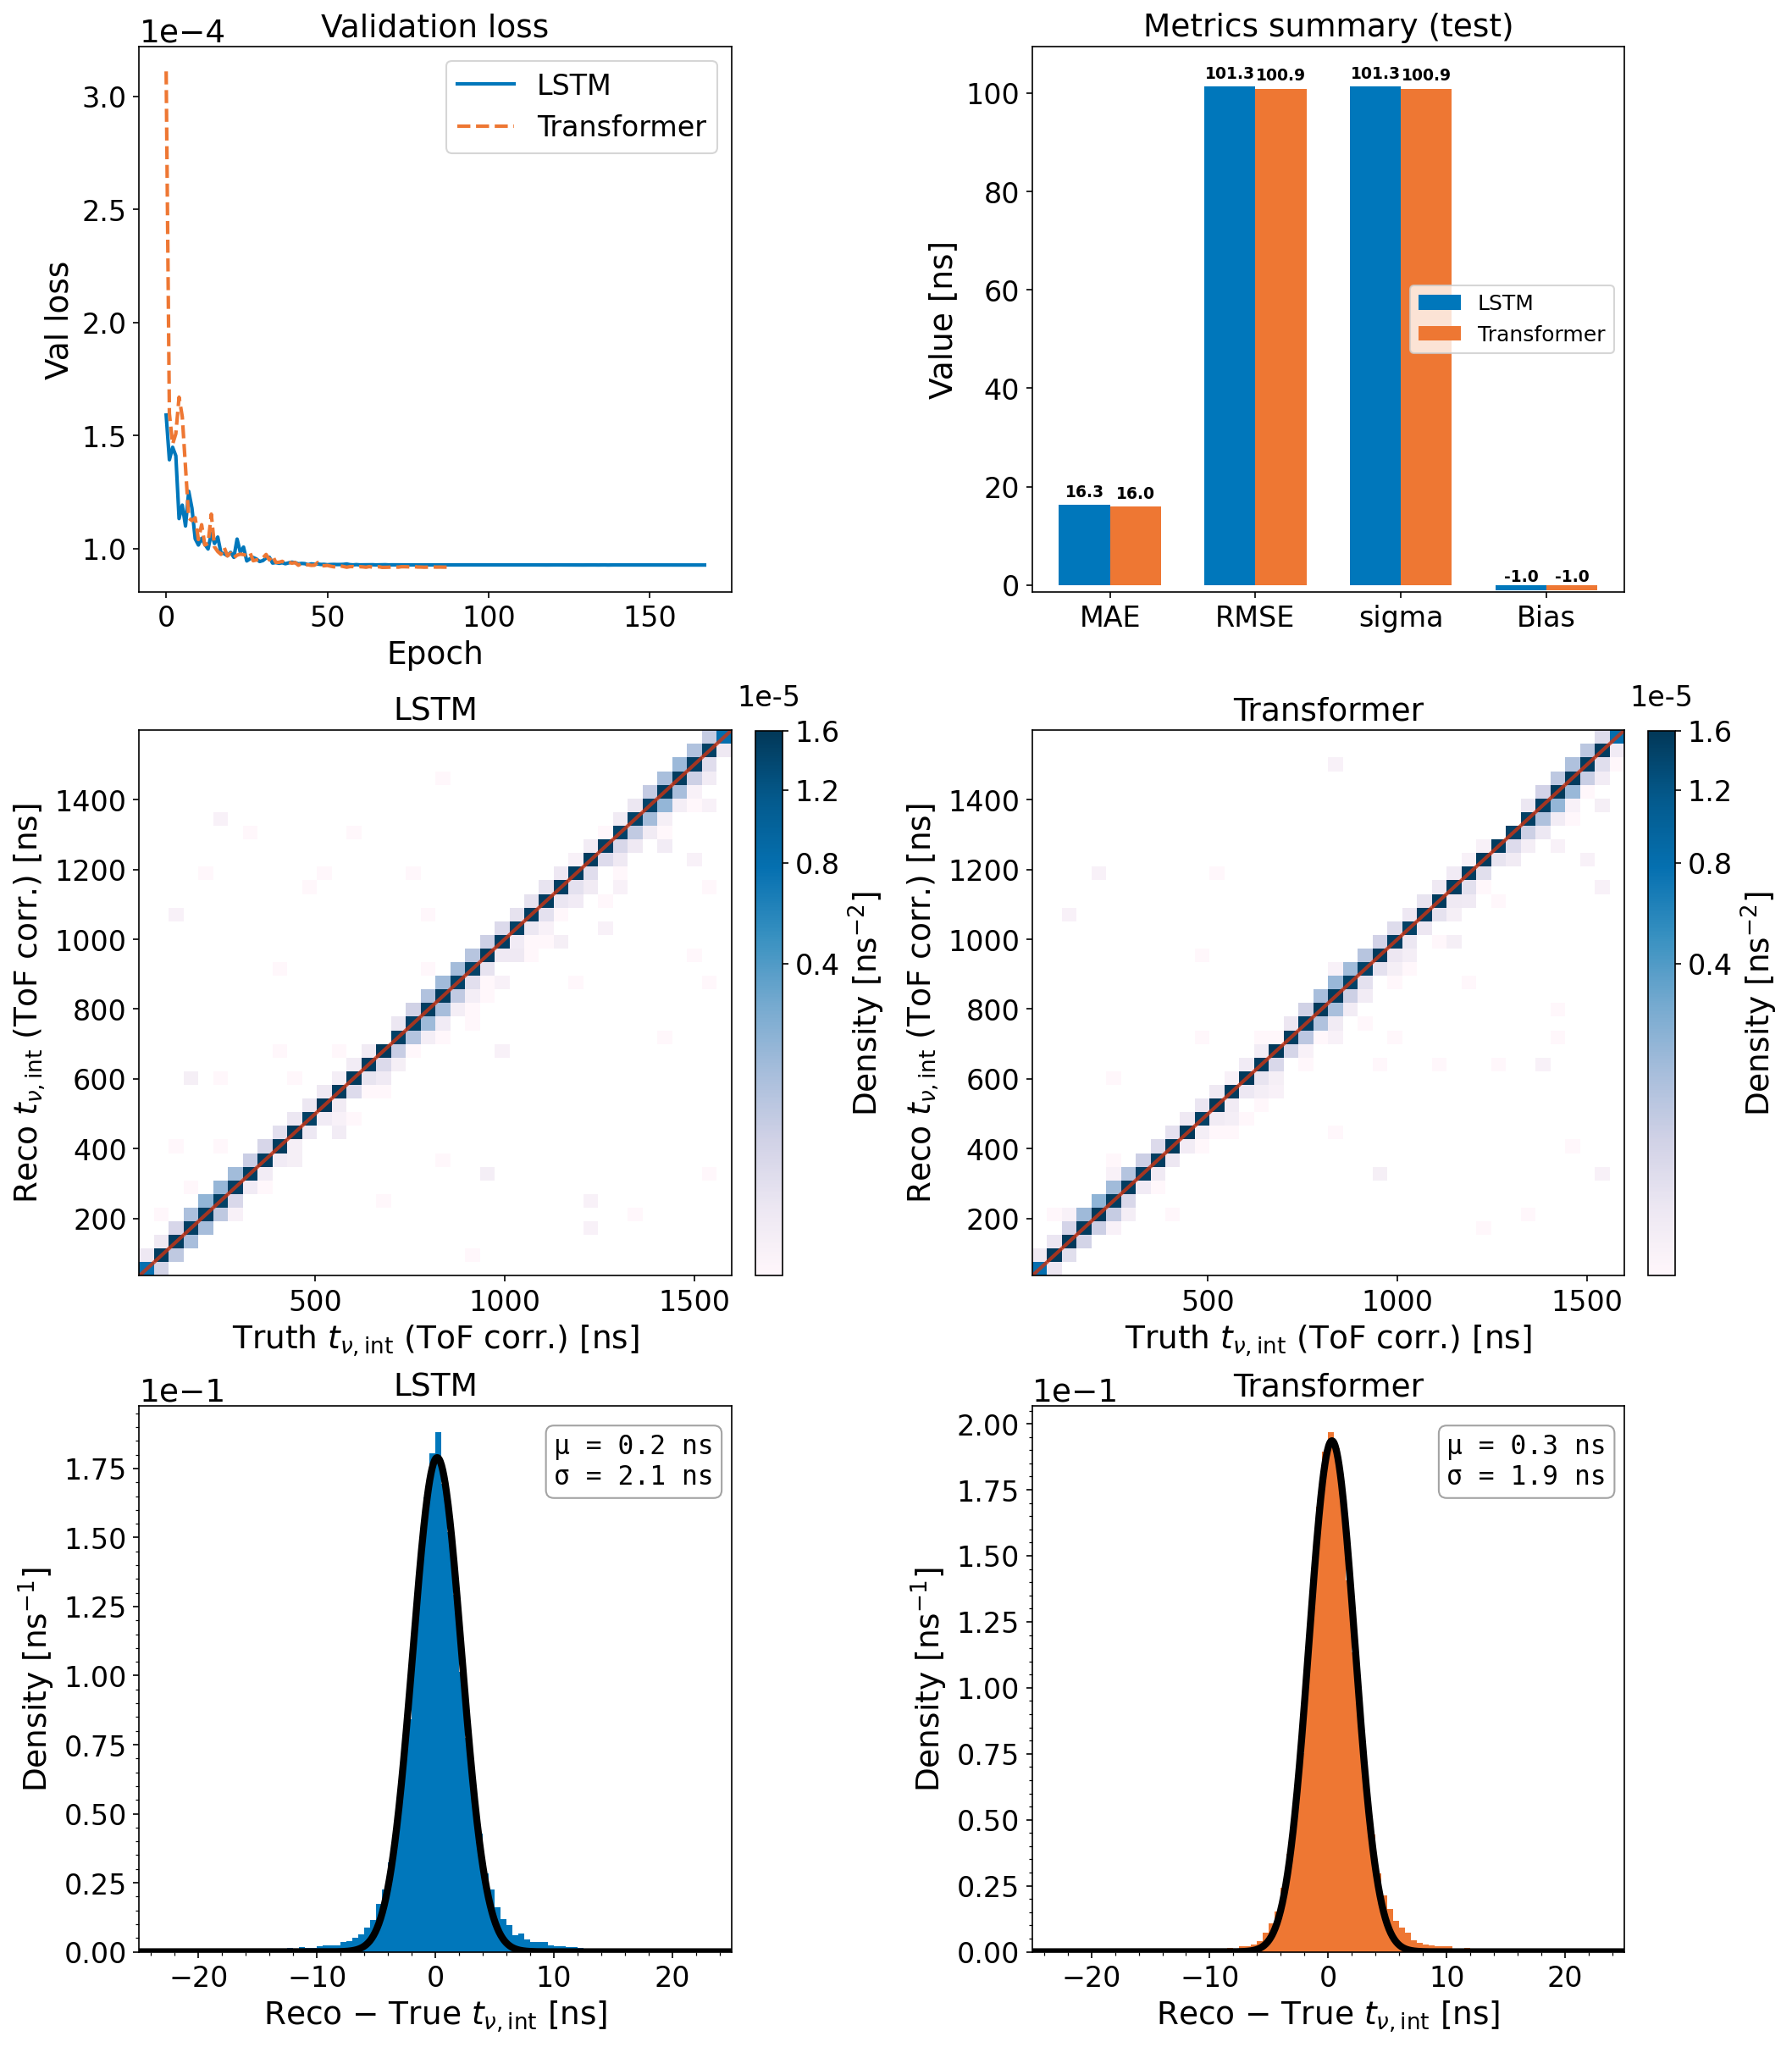

In [189]:
import math
import matplotlib.colors as mcolors
from matplotlib.ticker import AutoMinorLocator
# ── LSTM vs Transformer comparison — ToF (test set) ─────────────────────────
print('>> Running inference on test set...')
diff_lstm_tof_te, pred_lstm_ns = eval_on_test(model_lstm_tof, X_tof_te, label_tof_te, sc_tof)
diff_tof_te,      pred_tof_ns  = eval_on_test(model_tof,      X_tof_te, label_tof_te, sc_tof)

truth_ns = label_tof_te

LS_MAP = {'LSTM': '-', 'Transformer': '--'}
models_test = [
    ('LSTM',        pred_lstm_ns, hist_lstm_tof),
    ('Transformer', pred_tof_ns,  hist_tof),
]

print('\n' + '='*75)
print(f"  {'Model':<14} {'MAE':>8} {'RMSE':>9} {'Bias':>9} {'sigma_raw':>10} {'mu_gauss':>10} {'sigma_gauss':>12}")
print(f"  {'-'*14} {'-'*8} {'-'*9} {'-'*9} {'-'*10} {'-'*10} {'-'*12}")
fit_results = {}
for name, pred_ns, _ in models_test:
    res  = pred_ns - truth_ns
    popt, perr, bins, cnt, cx = fit_residuals(res)
    fit_results[name] = (popt, perr, bins, cnt, cx, res)
    print(f"  {name:<14} {np.abs(res).mean():>8.2f} {np.sqrt(np.mean(res**2)):>9.2f} "
          f"{np.mean(res):>9.2f} {np.std(res):>10.2f} {popt[1]:>10.2f} {abs(popt[2]):>12.2f}  ns")
print('='*75)

CMIN   = 1
COLORS_OPP = {'LSTM': C_SECONDARY, 'Transformer': C_PRIMARY}
RMIN   = float(truth_ns.min()) - 20
RMAX   = float(truth_ns.max()) + 20
rng    = [[RMIN, RMAX]] * 2

FLABEL = 18
FTICK  = 16
FSTAT  = 11
FTITLE = 18

fig, axes = plt.subplots(3, 2, figsize=(14, 16), constrained_layout=True)

# ── [0,0] Val loss ────────────────────────────────────────────────────────────
ax = axes[0, 0]
for name, _, hist in models_test:
    ax.plot(hist.history['val_loss'], label=name, color=COLORS[name], lw=2, ls=LS_MAP[name])
ax.set_xlabel('Epoch', fontsize=FLABEL)
ax.set_ylabel('Val loss', fontsize=FLABEL)
ax.set_title('Validation loss', fontsize=FTITLE)
ax.legend(fontsize=FTICK)
ax.tick_params(labelsize=FTICK)
ax.ticklabel_format(axis='y', style='sci', scilimits=(0, 0))
ax.yaxis.get_offset_text().set_fontsize(FLABEL)
ax.grid(False)


# ── [0,1] Metrics bar ────────────────────────────────────────────────────────
ax = axes[0, 1]
metric_labels = ['MAE', 'RMSE', 'sigma', 'Bias']
vals = {}
for name, pred_ns, _ in models_test:
    res  = pred_ns - truth_ns
    popt = fit_results[name][0]
    vals[name] = [np.abs(res).mean(), np.sqrt(np.mean(res**2)),
                  np.std(res), np.mean(res)]
x = np.arange(len(metric_labels))
w = 0.35
all_vals = [v for vl in vals.values() for v in vl]
vmax = max(abs(v) for v in all_vals)
ylim_top = vmax * 1.08
THRESH = vmax * 0.25
for i, (name, _, __) in enumerate(models_test):
    bars = ax.bar(x + (i - 0.5) * w, vals[name], w,
                  color=COLORS[name], label=name)
    for b, v in zip(bars, vals[name]):
        bh = b.get_height()
        ax.text(b.get_x() + b.get_width()/2, bh + vmax*0.01,
                f'{v:.1f}', ha='center', va='bottom',
                fontsize=FSTAT-2, fontweight='bold', color='black')
ax.set_xticks(x)
ax.set_xticklabels(metric_labels, fontsize=FTICK)
ax.set_ylabel('Value [ns]', fontsize=FLABEL)
ax.set_title('Metrics summary (test)', fontsize=FTITLE)
ax.legend(fontsize=12)
ax.tick_params(labelsize=FTICK)
ax.set_ylim(bottom=min(min(v for v in vals[n]) for n in vals) * 1.4,
            top=ylim_top)
ax.grid(False)

# ── [1,0] y [1,1] 2D truth-vs-reco ───────────────────────────────────────────
for col, (name, pred_ns, _) in enumerate(models_test):
    ax = axes[1, col]
    counts_raw, _, _ = np.histogram2d(truth_ns, pred_ns, bins=40, range=rng)
    hist, xe, ye = np.histogram2d(truth_ns, pred_ns, bins=40, range=rng, density=True)
    exp = int(math.floor(math.log10(hist.max()))) if hist.max() > 0 else 0
    hm  = np.ma.masked_where((hist <= 0) | (counts_raw < 5), hist / 10**exp)
    im  = ax.pcolormesh(xe, ye, hm.T, cmap=CMAP_2D, shading='auto',
                        norm=mcolors.PowerNorm(gamma=0.4))
    cb  = fig.colorbar(im, ax=ax, pad=0.04, fraction=0.046)
    cb.ax.tick_params(labelsize=FTICK)
    cb.set_label(r'Density [ns$^{-2}$]', fontsize=FLABEL)
    cb.ax.set_title(f'1e{exp}', fontsize=FTICK, pad=14)
    cb_max = float(hm.compressed().max()) if hm.count() > 0 else 1.0
    cb_ticks = np.linspace(cb_max / 4, cb_max, 4)
    cb.set_ticks(cb_ticks)
    cb.set_ticklabels([f'{t:.1f}' for t in cb_ticks])
    ax.plot([RMIN, RMAX], [RMIN, RMAX], '-', color=C_ALERT, lw=2, alpha=0.8)
    ax.set_xlabel(r'Truth $t_{\nu,\mathrm{int}}$ (ToF corr.) [ns]', fontsize=FLABEL)
    ax.set_ylabel(r'Reco $t_{\nu,\mathrm{int}}$ (ToF corr.) [ns]', fontsize=FLABEL)
    ax.set_title(name, fontsize=FTITLE)
    ax.tick_params(labelsize=FTICK)

# ── [2,0] y [2,1] Gaussianas ──────────────────────────────────────────────────
for col, (name, _, __) in enumerate(models_test):
    ax = axes[2, col]
    popt, perr, bins, cnt, cx = fit_results[name][:5]
    dbin = bins[1] - bins[0]
    cnt_d = cnt / (cnt.sum() * dbin)
    popt_d = [popt[0] / (cnt.sum() * dbin), popt[1], popt[2]]
    ax.bar(cx, cnt_d, width=dbin, color=COLORS[name])
    x_fit = np.linspace(bins[0], bins[-1], 2000)
    ax.plot(x_fit, gaussian(x_fit, *popt_d), color='black', lw=4)
    ax.text(0.97, 0.95,
            f'\u03bc = {popt[1]:.1f} ns\n'
            f'\u03c3 = {abs(popt[2]):.1f} ns',
            transform=ax.transAxes, fontsize=15, va='top', ha='right',
            family='monospace', bbox=STAT_BOX)
    ax.set_xlabel(r'Reco − True $t_{\nu,\mathrm{int}}$ [ns]', fontsize=FLABEL)
    ax.set_ylabel('Density [ns$^{-1}$]', fontsize=FLABEL)
    ax.set_title(name, fontsize=FTITLE)
    ax.tick_params(labelsize=FTICK)
    ax.set_xlim(-25, 25)
    ax.ticklabel_format(axis='y', style='sci', scilimits=(0, 0))
    ax.yaxis.get_offset_text().set_fontsize(FLABEL)
    ax.xaxis.set_minor_locator(AutoMinorLocator())
    ax.yaxis.set_minor_locator(AutoMinorLocator())
    ax.grid(False)

plt.savefig(os.path.join(RUN_DIR, 'lstm_vs_transformer_comparison.pdf'), bbox_inches='tight')
plt.savefig(os.path.join(RUN_DIR, 'lstm_vs_transformer_comparison.png'), dpi=SAVE_DPI, bbox_inches='tight')
plt.show()


### Visualize predicted time distributions with RF bunch structure
Plot the predicted neutrino times alongside the true times for both models, zoomed into the BNB beam spill window. Vertical lines mark the expected positions of the RF buckets separated by the BNB RF period (18.936 ns). A well-trained model should reproduce the periodic bunch structure visible in the true distribution, confirming that the network has learned the underlying timing pattern rather than just the spill envelope.

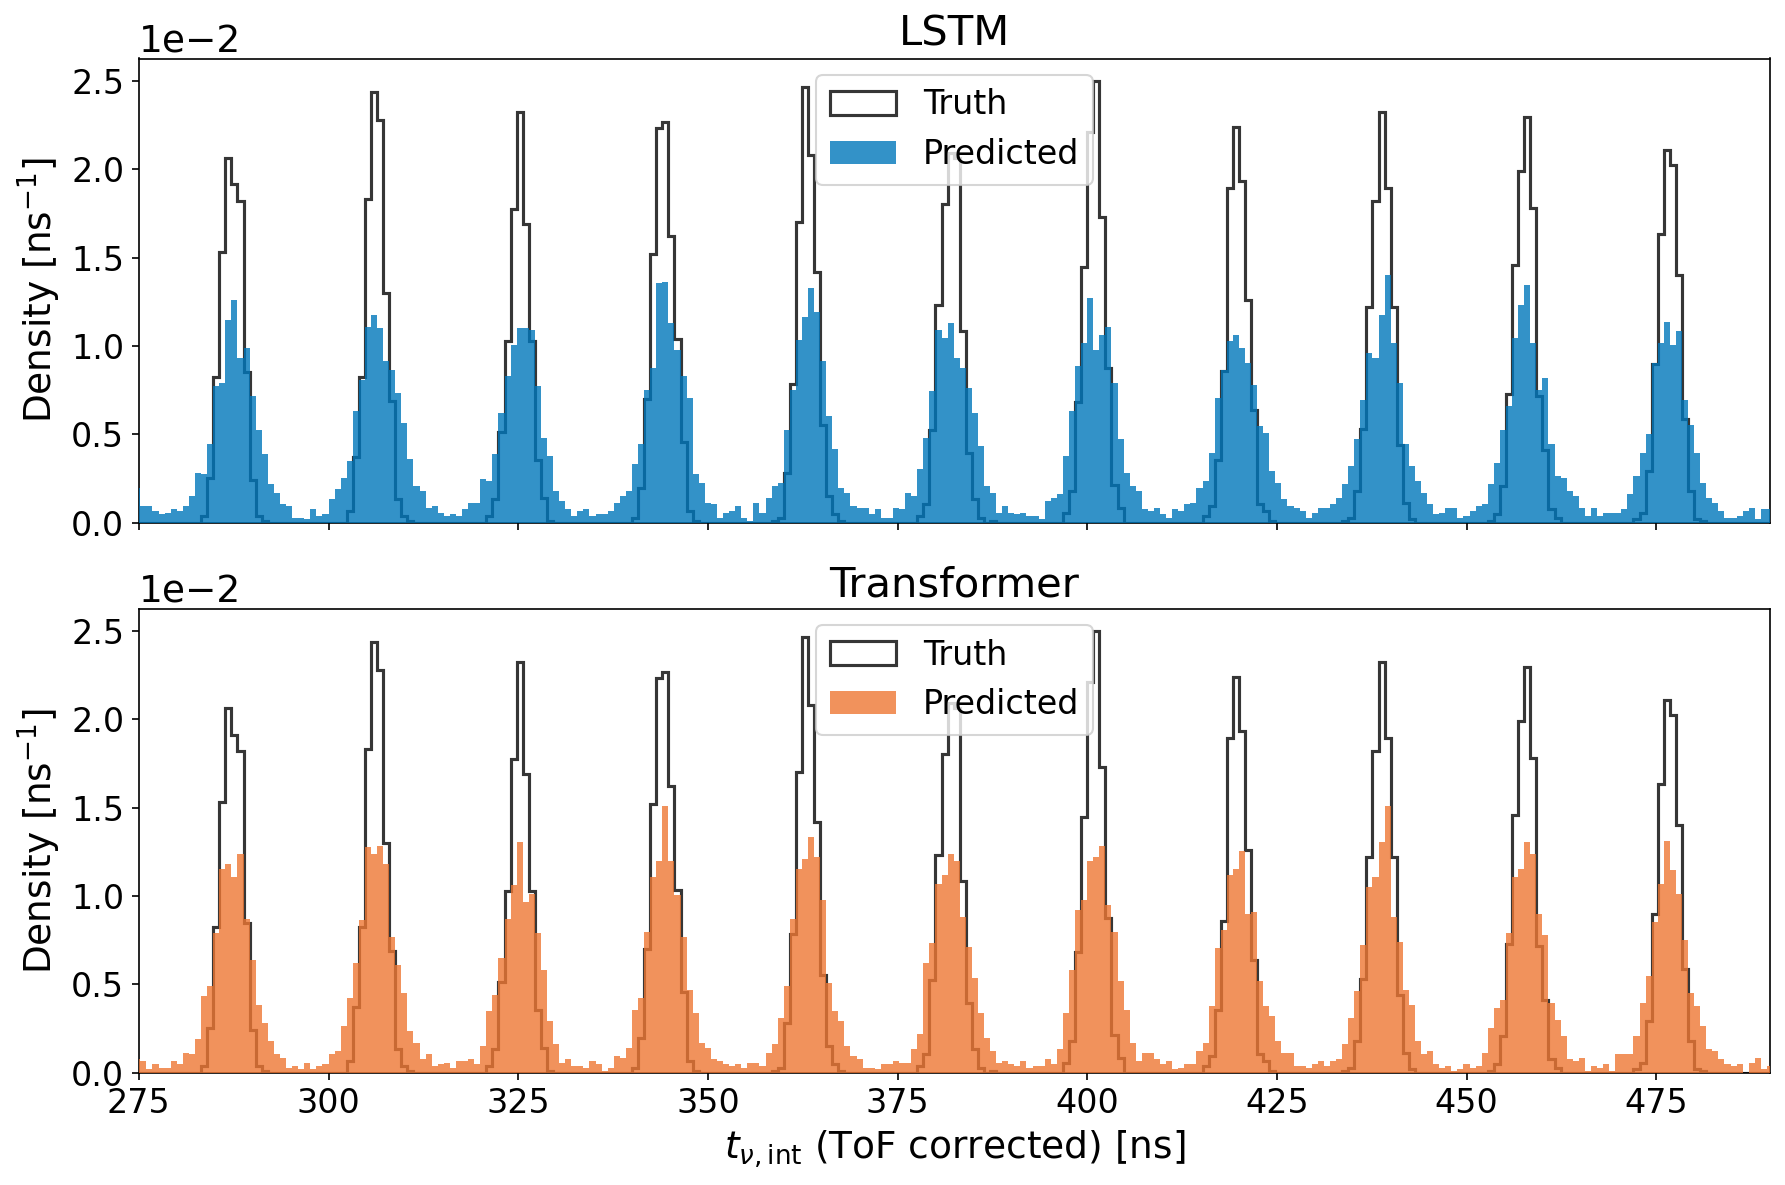

In [182]:
RF_PERIOD_NS = 18.936

zoom_min, zoom_max = 275, 490
hist_min, hist_max = 260, 500   # wider range to avoid edge cuts

t0 = zoom_min + (RF_PERIOD_NS - (zoom_min % RF_PERIOD_NS))
bunch_lines = np.arange(t0, zoom_max, RF_PERIOD_NS)

fig, axes = plt.subplots(2, 1, figsize=(12, 8), sharex=True, sharey=True)

for col, (name, pred_ns) in enumerate([('LSTM', pred_lstm_ns), ('Transformer', pred_tof_ns)]):
    color = COLORS[name]
    ax    = axes[col]

    ax.hist(truth_ns, bins=300, range=(hist_min, hist_max),
            histtype='step', color='#333333',alpha=0.99, lw=1.5, label='Truth', zorder=2, density=True)
    ax.hist(pred_ns, bins=300, range=(hist_min, hist_max),
            color=color, alpha=0.80, label='Predicted', zorder=3, density=True)

    ax.set_xlim(zoom_min, zoom_max)
    ax.set_title(name, fontsize=20)
    ax.set_xlabel(r'$t_{\nu,\mathrm{int}}$ (ToF corrected) [ns]' if col == 1 else '', fontsize=18)
    ax.set_ylabel('Density [ns$^{-1}$]', fontsize=18)
    ax.tick_params(labelsize=16)
    ax.ticklabel_format(axis='y', style='sci', scilimits=(0, 0))
    ax.yaxis.get_offset_text().set_fontsize(18)
    ax.legend(fontsize=16)

plt.tight_layout()
plt.savefig(os.path.join(RUN_DIR, 'lstm_vs_transformer_bnb_bunches.pdf'), bbox_inches='tight')
plt.savefig(os.path.join(RUN_DIR, 'lstm_vs_transformer_bnb_bunches.png'), dpi=SAVE_DPI, bbox_inches='tight')
plt.show()

### Fit the full-range RF bunch structure
Extend the bunch-structure analysis to the full spill range (0 – 1600 ns). Fit a comb of Gaussians (one per RF bucket) to the predicted time histogram to extract the reconstructed bunch width and inter-bunch spacing.

Data range: 55 – 1600 ns


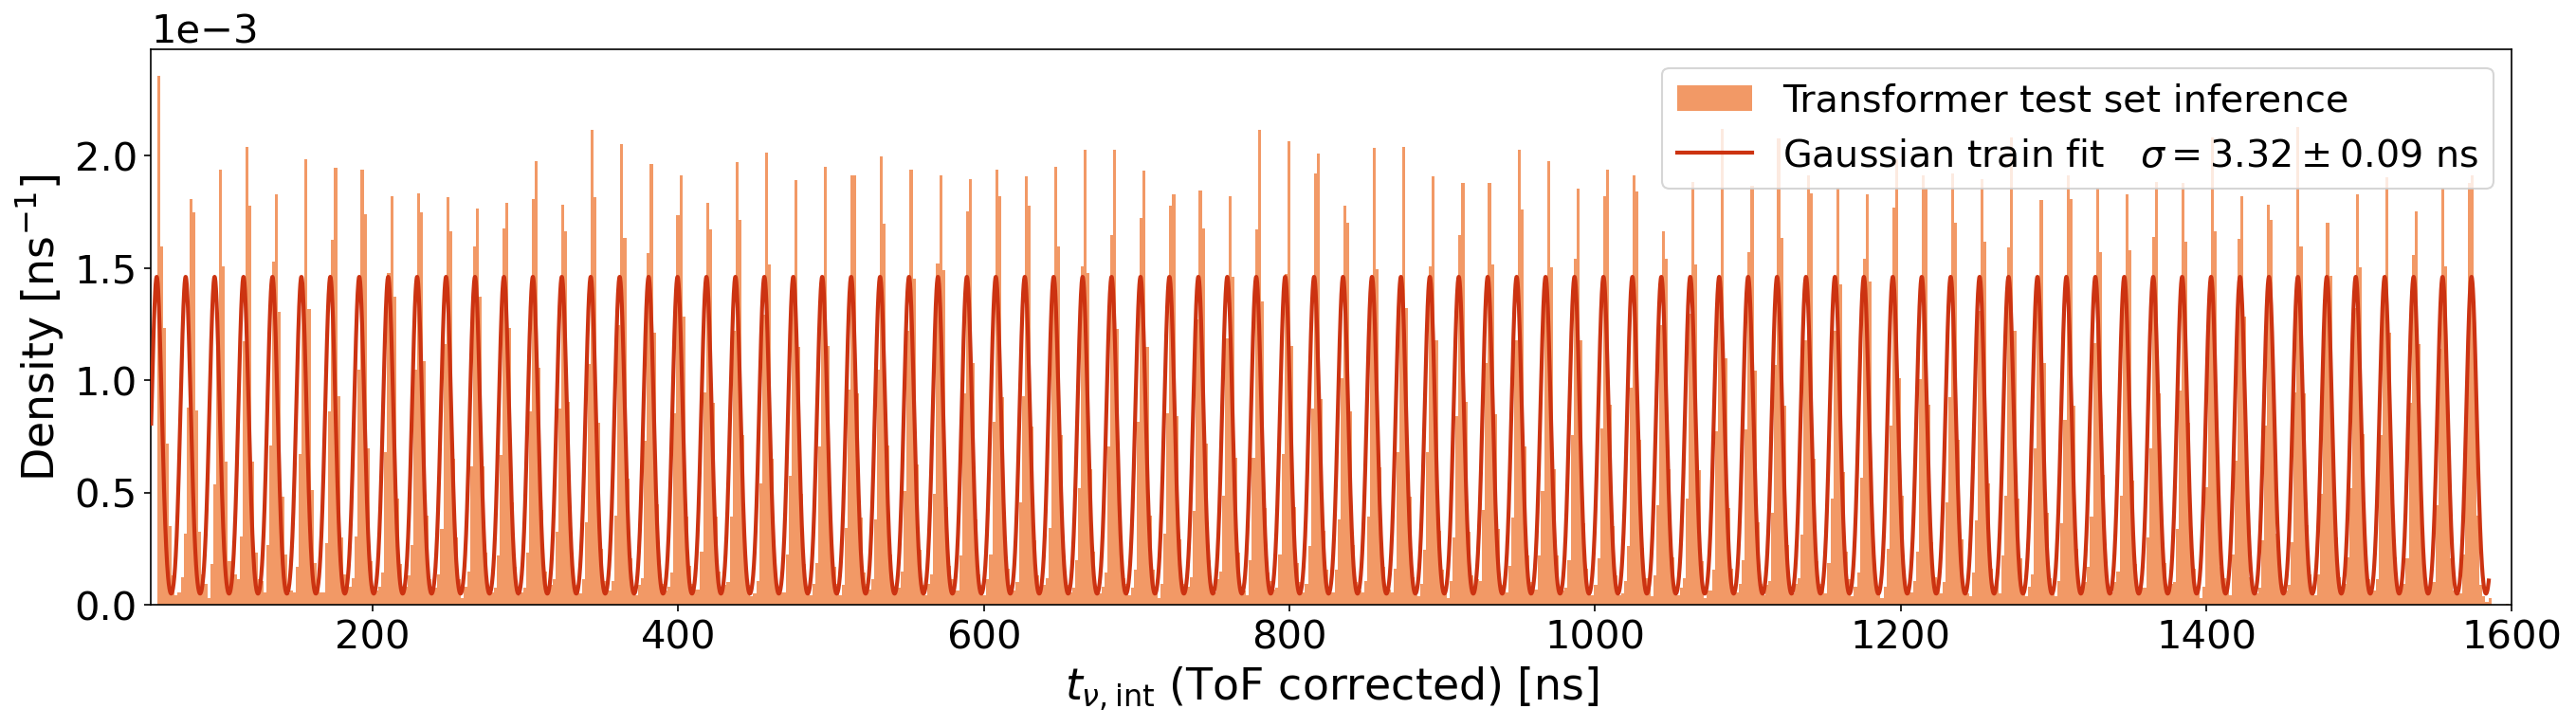

Gaussian train fit:  sigma = 3.318 +/- 0.088 ns


In [190]:
from scipy.optimize import curve_fit

# ── Full-range bunch parameters ───────────────────────────────────────────────
# Use actual data range
FULL_MIN = max(0,    int(np.floor(pred_tof_ns.min())) - 5)
FULL_MAX = 1600
print(f'Data range: {FULL_MIN:.0f} – {FULL_MAX:.0f} ns')
t0_full          = RF_PERIOD_NS - (FULL_MIN % RF_PERIOD_NS)
bunch_lines_full = np.arange(t0_full, FULL_MAX, RF_PERIOD_NS)
bunch_lines_full = bunch_lines_full[bunch_lines_full <= 1600]

# ── Histogram of Transformer predicted (full range) ───────────────────────────
counts_p, edges_p = np.histogram(pred_tof_ns, bins=800, range=(FULL_MIN, 1600), density=True)
cx_p = 0.5 * (edges_p[:-1] + edges_p[1:])

# Gaussian train: uniform amplitude, fit A and sigma
def gaussian_train_full(t, A, sigma):
    result = np.zeros_like(t, dtype=float)
    for t_b in bunch_lines_full:
        result += A * np.exp(-(t - t_b)**2 / (2.0 * sigma**2))
    return result

popt_tr, pcov_tr = curve_fit(
    gaussian_train_full, cx_p, counts_p,
    p0=[0.02, 2.5], bounds=([0, 0.1], [1.0, 20.0])
)
A_fit, sigma_fit = popt_tr
sigma_err = np.sqrt(pcov_tr[1, 1])

t_fine    = np.linspace(FULL_MIN, 1584.8, 10000)
fit_curve = gaussian_train_full(t_fine, *popt_tr)

# ── Plot ─────────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(18, 5), constrained_layout=True)

ax.hist(pred_tof_ns, bins=800, range=(FULL_MIN, 1600), density=True,
        color=C_SECONDARY, alpha=0.75, label='Transformer test set inference', zorder=2)
ax.plot(t_fine, fit_curve, color=C_ALERT, lw=2,
        label=f'Gaussian train fit   $\\sigma={sigma_fit:.2f}\\pm{sigma_err:.2f}$ ns', zorder=3)

ax.set_xlim(FULL_MIN, 1600)
ax.set_xlabel(r'$t_{\nu,\mathrm{int}}$ (ToF corrected) [ns]', fontsize=22)
ax.set_ylabel('Density [ns$^{-1}$]', fontsize=22)
ax.tick_params(labelsize=20)
ax.ticklabel_format(axis='y', style='sci', scilimits=(0, 0))
ax.yaxis.get_offset_text().set_fontsize(20)
ax.legend(fontsize=19)

plt.savefig(os.path.join(RUN_DIR, 'transformer_bunch_fit.pdf'), bbox_inches='tight')
plt.savefig(os.path.join(RUN_DIR, 'transformer_bunch_fit.png'), dpi=SAVE_DPI, bbox_inches='tight')
plt.show()

print(f'Gaussian train fit:  sigma = {sigma_fit:.3f} +/- {sigma_err:.3f} ns')


### Plot BNB bunch structure in nanoseconds (supplementary)
Additional visualization showing the raw and ToF-corrected neutrino times across the full spill in nanoseconds. The ToF correction `nuvT_tof = nuvT − nuvZ / c` removes the propagation delay of neutrinos from the target to the detector, aligning events from different Z positions onto a common timing reference. This plot is used to verify the correction and to illustrate the bunch structure for presentations.

Bunch offset: 268.57 ns  (first peak of ToF corrected)


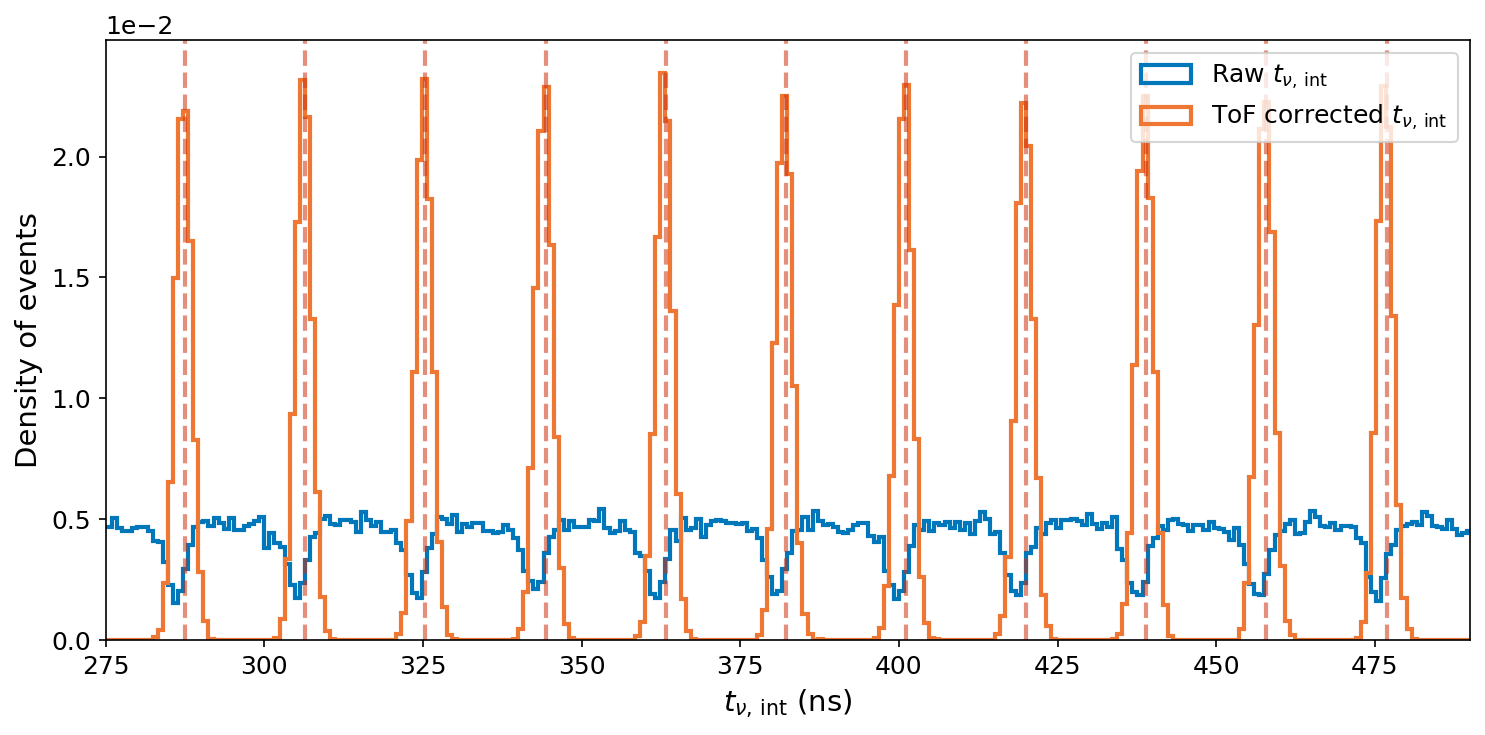

Mean ToF shift: 8.17 ns  (= mean nuvZ/c)
Figures saved in /exp/sbnd/data/users/svidales/AI_nuvT_project_support/AA_FinalPlots/temporal/runs/run_20260415_1214


In [179]:
import os
nuvT_tof_all = (nuvT_all - nuvZ_all / C_LIGHT_CM_NS)

nuvT_us     = nuvT_all     / 1e3
nuvT_tof_us = nuvT_tof_all / 1e3

# nanoseconds versions (for bunch structure plot)
nuvT_ns     = nuvT_all
nuvT_tof_ns = nuvT_tof_all

SPILL_MIN_US, SPILL_MAX_US = 0.0, 1.6
RF_PERIOD_US = 18.936e-3
RF_PERIOD_NS = 18.936

# ── Figure : BNB bunch structure (nanoseconds) ───────────────────────────────
zoom_min_ns, zoom_max_ns = 275, 490
hist_min_ns, hist_max_ns = 260, 500

# Find bunch offset from data: peak of first bunch in ToF corrected histogram
cnt_ref, edges_ref = np.histogram(nuvT_tof_ns, bins=2000,
                                   range=(hist_min_ns, hist_min_ns + RF_PERIOD_NS * 2))
cx_ref = (edges_ref[:-1] + edges_ref[1:]) / 2
first_peak_ns = cx_ref[cnt_ref.argmax()]
bunch_lines_ns = np.arange(first_peak_ns, zoom_max_ns + RF_PERIOD_NS, RF_PERIOD_NS)
bunch_lines_ns = bunch_lines_ns[(bunch_lines_ns >= zoom_min_ns) & (bunch_lines_ns <= zoom_max_ns)]
print(f'Bunch offset: {first_peak_ns:.2f} ns  (first peak of ToF corrected)')

fig, ax = plt.subplots(figsize=(10, 5))
ax.hist(nuvT_ns,     bins=300, range=(hist_min_ns, hist_max_ns),
        density=True, histtype='step', color=C_PRIMARY,  lw=2,
        label=r'Raw $t_{\nu,\,\mathrm{int}}$')
ax.hist(nuvT_tof_ns, bins=300, range=(hist_min_ns, hist_max_ns),
        density=True, histtype='step', color=C_SECONDARY, lw=2,
        label=r'ToF corrected $t_{\nu,\,\mathrm{int}}$')
for t_b in bunch_lines_ns:
    ax.axvline(t_b, color=C_ALERT, alpha=0.55, lw=2, ls='--')
ax.set_xlim(zoom_min_ns, zoom_max_ns)
ax.set_xlabel(r'$t_{\nu,\,\mathrm{int}}$ (ns)')
ax.set_ylabel('Density of events')
ax.ticklabel_format(axis='y', style='sci', scilimits=(0, 0))
ax.yaxis.get_offset_text().set_fontsize(mpl.rcParams['ytick.labelsize'])
ax.legend(loc='upper right')
plt.tight_layout()
plt.savefig(os.path.join(RUN_DIR, 'nuvT_bnb_bunch_structure.pdf'), bbox_inches='tight')
plt.savefig(os.path.join(RUN_DIR, 'nuvT_bnb_bunch_structure.png'), dpi=SAVE_DPI, bbox_inches='tight')
plt.show()

print(f'Mean ToF shift: {(nuvT_us - nuvT_tof_us).mean()*1e3:.2f} ns  (= mean nuvZ/c)')
print(f'Figures saved in {RUN_DIR}')